In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mansoordaku/ckdisease")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ckdisease' dataset.
Path to dataset files: /kaggle/input/ckdisease


In [ ]:
df = pd.read_csv("/kaggle/input/ckdisease/kidney_disease.csv")

In [ ]:
df = df.drop("id", axis=1)

In [ ]:
y = df["classification"]
X = df.drop("classification", axis=1)

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X = X.fillna(X.mean())

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.04045813 0.01655587]


In [ ]:
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["classification"] = y
print("\nFirst 5 rows of PCA Output:")
print(pca_df.head())


First 5 rows of PCA Output:
        PC1       PC2 classification
0  0.749104 -0.969713            ckd
1  1.377728  0.088485            ckd
2 -3.165099 -1.360507            ckd
3 -3.402215  1.147151            ckd
4  1.046905 -0.601986            ckd


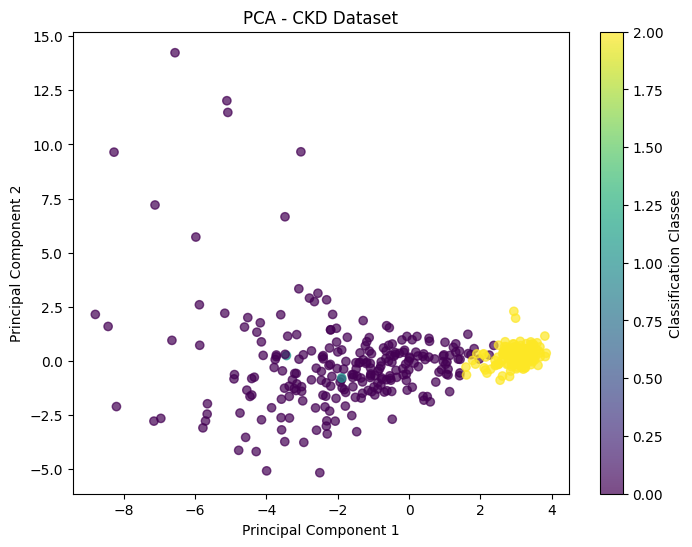

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(pca_df["PC1"], pca_df["PC2"],
            c=pd.factorize(pca_df["classification"])[0],
            alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - CKD Dataset")
plt.colorbar(label="Classification Classes")
plt.show()

In [ ]:
pca_full = PCA(0.95)
X_reduced = pca_full.fit_transform(X_scaled)
print("\nNumber of PCA components to retain 95% variance:")
print(pca_full.n_components_)
print("\nTotal variance retained:")
print(sum(pca_full.explained_variance_ratio_))


Number of PCA components to retain 95% variance:
152

Total variance retained:
0.9502519837093574
